In [1]:
# Import libaries
import matplotlib
import numpy as np
import scipy as sci
import sympy as sym
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
# from ipywidgets import interact

In [2]:
# Define function to calculate magnetic field
def MagneticVectorField(l_, mesh):
    # Unpack l_
    # The function that describes the loop
    l = l_[0]
    # The domain of the loop, from a to b
    a = l_[1][0]
    b = l_[1][1]
    # The parameter of the loop
    v = l_[2]

    # Unpack the meshgrid
    # r = mesh[0]
    # a_ = mesh[0][0][0]
    # b_ = mesh[0][-1][0]
    # phi = mesh[1]
    # theta = mesh[2]
    xp = mesh[0]
    yp = mesh[1]
    zp = mesh[2]

    # Create the xyz grid inside the toroid
    # xp = (a_ + r*np.sin(theta))*np.cos(phi)
    # yp = (a + r*np.sin(theta))*np.sin(phi)
    # zp = b_*np.cos(theta)

    # Initialize symbols and vectors
    # Use the same symbols when defining the loops
    x, y, z = sym.symbols('x, y, z')
    r = sym.Matrix([x, y, z])
    sep = r - l

    # Define integrand
    # v is the variable that is going to be integrated
    integrand = sym.diff(l, v).cross(sep)/sep.norm()**3

    # Separate integrand into the coordinates
    dBxdv = sym.lambdify([v, x, y, z], integrand[0])
    dBydv = sym.lambdify([v, x, y, z], integrand[1])
    dBzdv = sym.lambdify([v, x, y, z], integrand[2])

    # Function to integrate over the loop at a given point
    def B(x, y, z):
        X = sci.integrate.quad(dBxdv, a, b, args=(x, y, z))[0]
        Y = sci.integrate.quad(dBydv, a, b, args=(x, y, z))[0]
        Z = sci.integrate.quad(dBzdv, a, b, args=(x, y, z))[0]
        return np.array([X, Y, Z])

    # Calculate the magnetic field at every point of the meshgrid
    B_grid = np.vectorize(B, signature='(),(),()->(n)')(xp, yp, zp)

    # Extract the components into separate arrays
    # 3D meshgrid
    # Bx = B_grid[:, :, :, 0]
    # By = B_grid[:, :, :, 1]
    # Bz = B_grid[:, :, :, 2]
    # 2D meshgird
    Bx = B_grid[:, :, 0]
    By = B_grid[:, :, 1]
    Bz = B_grid[:, :, 2]

    return np.array([Bx, By, Bz])

In [3]:
# Create meshgrid space
# Torus parameters
a = 1
b = 0.5
# Rectanguar meshgrid
n_points = 20
points = np.linspace(-1.5, 1.5, n_points)
xp, yp, zp = np.meshgrid(points, points, points)
# mesh = np.array([xp, yp, zp])
mesh = np.array([xp[int(len(xp)/2)], yp[int(len(xp)/2)], zp[int(len(xp)/2)]])
# For toroidal cross section
# mesh = np.array([xp[:, :, int(len(xp)/2)], yp[:, :, int(len(xp)/2)], zp[:, :, int(len(xp)/2)]])

# Toroidal meshgrid
# theta = np.linspace(0, 2*np.pi, 15)
# theta = theta[0: -1]
# r = np.linspace(0, b, 5)
# phi = np.linspace(0, 2*np.pi, 15)
# phi = phi[0:-1]
# R, Theta, Phi = np.meshgrid(r, theta, phi)
# xp = (a + b*np.sin(Theta))*np.sin(Phi)
# yp = -(a + b*np.sin(Theta))*np.cos(Phi)
# zp = (b + 0.3)*np.cos(Theta)
# mesh = np.array([xp, yp, zp])

In [4]:
# Create loop functions
# Poloidal loop
def PoloidalLoop (r, h):
    # Parameter of the loop
    phi = sym.symbols('\\phi')

    # Create sympy loop, domain and pack
    x_ = r*sym.sin(phi)
    y_ = -r*sym.cos(phi)
    z_ = h
    loop = sym.Matrix([x_, y_, z_])
    domain = np.array([2*np.pi, 0])
    sym_pack = [loop, domain, phi]

    # Create loop coordiantes to plot
    phi_ = np.linspace(domain[0], domain[-1], 100)
    X = r*np.sin(phi_)
    Y = -r*np.cos(phi_)
    Z = np.full(len(phi_), h)
    ploop = np.array([X, Y, Z])

    return [sym_pack, ploop]

# Central solenoid
def CentralSolenoid (n): 
    # Parameter of the coil
    zs = sym.symbols('zs')

    # Create sympy loop, domain and pack
    r = a - b - 0.3
    x_ = r*sym.sin((n*2*np.pi*(b+zs))/(2*b))
    y_ = -r*sym.cos((n*2*np.pi*(b+zs))/(2*b))
    z_ = zs
    loop = sym.Matrix([x_, y_, z_])
    domain = np.array([-(b + 0.2), (b + 0.2)])
    sym_pack = [loop, domain, zs]

    # Create plot loop coordinates to plot
    zl = np.linspace(domain[0], domain[-1], 200)
    X = r*np.sin((n*2*np.pi*(b+zl))/(2*b))
    Y = -r*np.cos((n*2*np.pi*(b+zl))/(2*b))
    Z = zl
    ploop = np.array([X, Y, Z])

    return [sym_pack, ploop]

# Toroidal field coil
def ToroidalCoil (n):
    # Parameter of the coil
    phi = sym.symbols('\\phi')

    # Create sympy loop, domain and pack
    radius = b + 0.2
    x_ = (a + radius*sym.sin(n*phi))*sym.sin(phi)
    y_ = -(a + radius*sym.sin(n*phi))*sym.cos(phi)
    z_ = (radius + 0.3)*sym.cos(n*phi)
    loop = sym.Matrix([x_, y_, z_])
    domain = np.array([0, 2*np.pi])
    sym_pack = [loop, domain, phi]

    # Create plot loop coordinates to plot
    phi_ = np.linspace(domain[0], domain[-1], 400)
    X = (a + radius*np.sin(n*phi_))*np.sin(phi_)
    Y = -(a + radius*np.sin(n*phi_))*np.cos(phi_)
    Z = (radius + 0.3)*np.cos(n*phi_)
    ploop = np.array([X, Y, Z])

    return [sym_pack, ploop]

In [5]:
### Calculation of the central solenoid field
loop_cs = CentralSolenoid(15)
sym_loop_cs = loop_cs[0]
ploop_cs = loop_cs[1]
field_cs = MagneticVectorField(sym_loop_cs, mesh)

field = field_cs
###

/tmp/ipykernel_3115/219583426.py:46: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  Z = sci.integrate.quad(dBzdv, a, b, args=(x, y, z))[0]
/tmp/ipykernel_3115/219583426.py:44: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps 

In [ ]:
### Calculation for the plasma current
loop_plasma = PoloidalLoop(a, 0)
sym_loop_plasma = loop_plasma[0]
ploop_plasma = loop_plasma[1]
field_plasma = MagneticVectorField(sym_loop_plasma, mesh)

field = field_plasma

In [ ]:
# Calculate 1D magnetic flux for the central solenoid and plasma current
# Central solenoid flux, just adding the vertical components of the field
flux_cs = 0
for i in range(len(xp[int(len(xp)/2)][:, int(len(xp)/2)])):
    if abs(xp[int(len(xp)/2)][:, int(len(xp)/2)][i]) < a:
        flux_cs += 2*field_cs[2][:, int(len(xp)/2)][i]
print(flux_cs)
# Plasma current flux, same thing
flux_plasma = 0
for i in range(len(xp[int(len(xp)/2)][:, int(len(xp)/2)])):
    if abs(xp[int(len(xp)/2)][:, int(len(xp)/2)][i]) < a:
        flux_plasma += 2*field_plasma[2][:, int(len(xp)/2)][i]
print(flux_plasma)
flux_ratio = abs(flux_cs/flux_plasma)
print('---')
print(flux_ratio)

In [ ]:
### Calculation of the toroidal coil field
loop_tor = ToroidalCoil(20)
sym_loop_tor = loop_tor[0]
ploop_tor = loop_tor[1]
field_tor = MagneticVectorField(sym_loop_tor, mesh)

field = field_tor

In [ ]:
### Calculation for the poloidal loops
loop_1 = PoloidalLoop(a + 0.5, b + 0.3)
sym_loop_1 = loop_1[0]
ploop_1 = loop_1[1]
field_1 = MagneticVectorField(sym_loop_1, mesh)

loop_2 = PoloidalLoop(a + 0.5, -b - 0.3)
sym_loop_2 = loop_2[0]
ploop_2 = loop_2[1]
field_2 = MagneticVectorField(sym_loop_2, mesh)

loop_3 = PoloidalLoop(a + b + 0.1, b/2)
sym_loop_3 = loop_3[0]
ploop_3 = loop_3[1]
field_3 = MagneticVectorField(sym_loop_3, mesh)

loop_4 = PoloidalLoop(a + b + 0.1, -b/2)
sym_loop_4 = loop_4[0]
ploop_4 = loop_4[1]
field_4 = MagneticVectorField(sym_loop_4, mesh)


field = field_1 + field_2 + field_3 + field_4

In [ ]:
# Add the fields of all the coils
field = 10*field_1 + 10*field_2 + 7*field_cs + field_tor
field =  7*field_plasma + field_tor
# Normalize lenght
field = field/(np.sqrt(field[0]**2 + field[1]**2 + field[2]**2))

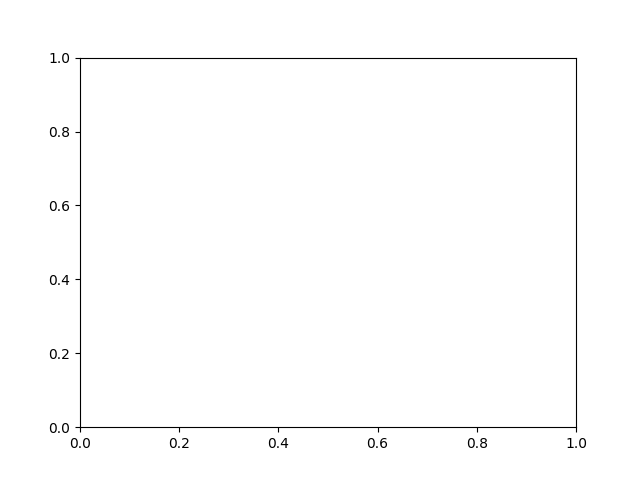

In [25]:
# Plot the results

%matplotlib widget
# For 3D plot
# fig_1 = plt.figure()
# ax_1 = fig_1.add_subplot(111, projection='3d')

# For 2D plot
fig_2 = plt.figure()
ax_2 = fig_2.add_subplot(111)
# fig_2, ax_2 = plt.subplots(figsize=(4, 3))

In [ ]:
### Central solenoid 3D plot
ax_1.plot(ploop_cs[0], ploop_cs[1], ploop_cs[2], color='green', label='Central solenoid')
ax_1.quiver(xp, yp, zp, field[0], field[1], field[2], length=0.3, normalize=True)

In [ ]:
### Plasma current 3D plot
ax_1.plot(ploop_plasma[0], ploop_plasma[1], ploop_plasma[2], color='red', label='Plasma current')
ax_1.quiver(xp, yp, zp, field[0], field[1], field[2], length=0.3, normalize=True)

In [ ]:
### Toroidal field 3D plot
ax_1.plot(ploop_tor[0], ploop_tor[1], ploop_tor[2], color='black', label='Toroidal coil')
ax_1.quiver(xp, yp, zp, field[0], field[1], field[2], length=0.3, normalize=True)

In [ ]:
### Poloidal field 3D plot
# Plot the loops and the field they generate
ax_1.plot(ploop_1[0], ploop_1[1], ploop_1[2], color='blue', label='Poloidal coils')
ax_1.plot(ploop_2[0], ploop_2[1], ploop_2[2], color='blue')
ax_1.plot(ploop_3[0], ploop_3[1], ploop_3[2], color='blue')
ax_1.plot(ploop_4[0], ploop_4[1], ploop_4[2], color='blue')
ax_1.quiver(xp, yp, zp, field[0], field[1], field[2], length=0.3, normalize=True)

In [ ]:
### All fields 3D plot
# Create new meshgrids to plot with plotly
Theta_ = np.linspace(0, 2*np.pi, 15)
# Theta_ = Theta_[0: -1]
Phi_ = np.linspace(0, 2*np.pi, 15)
# Phi_ = Phi_[0: -1]
theta_, phi_ = np.meshgrid(Theta_, Phi_)

xs = (a + b*np.sin(theta_))*np.sin(phi_)
ys = -(a + b*np.sin(theta_))*np.cos(phi_)
zs = (b + 0.3)*np.cos(theta_)

# # Use plotly
pio.renderers.default = 'firefox'

fig = go.Figure()
fig.add_trace(go.Surface(x=xs, y=ys, z=zs, colorscale='Gray'))

fig.add_trace(go.Cone(x=xp.flatten(), y=yp.flatten(), z=zp.flatten(),
                       u=field[0].flatten(), v=field[1].flatten(), w=field[2].flatten(),
                       sizemode="absolute", sizeref=2, colorscale=[[0, 'rgb(0,0,0)'], [1, 'rgb(0,0,0)']], anchor="tail"))

fig.update_traces(showscale=False)
fig.show()

In [ ]:
# Changes to make the plot look as expected
ax_1.set_xlim(-b-a,b+a) 
ax_1.set_ylim(-b-a,b+a)
ax_1.set_zlim(-b-a,b+a) 
plt.legend()
plt.show()

In [ ]:
### Poloidal field cross section
### For a mesh, send the p[int(len(xp)/2)] components, to the field calculator
### Also use the 2D field option of the calculator. Then just plot. Streamplot look very ugly
# # Plot the field
rn = (np.sqrt(field[0]**2 + field[2]**2))**(1)
ax_2.quiver(xp[int(len(xp)/2)], zp[int(len(xp)/2)], field[0]/rn, field[2]/rn, color='purple')

# # Circle patch for the torus walls
circ_1 = matplotlib.patches.Ellipse((1, 0), 1, 1.6, color=None, fill=False, label='Torus walls')
circ_2 = matplotlib.patches.Ellipse((-1, 0), 1, 1.6, color=None, fill=False)
ax_2.add_patch(circ_1)
ax_2.add_patch(circ_2)

# # Lines to represent the coils
ax_2.plot(ploop_1[0], ploop_1[2], color='blue', label='Poloidal coils')
ax_2.plot(ploop_2[0], ploop_2[2], color='blue')
ax_2.scatter(-a - b - 0.1, b/2, color='blue')
ax_2.scatter(a + b + 0.1, b/2, color='blue')
ax_2.scatter(-a - b - 0.1, -b/2, color='blue')
ax_2.scatter(a + b + 0.1, -b/2, color='blue')

ax_2.set_aspect('equal')
plt.legend()
plt.show()

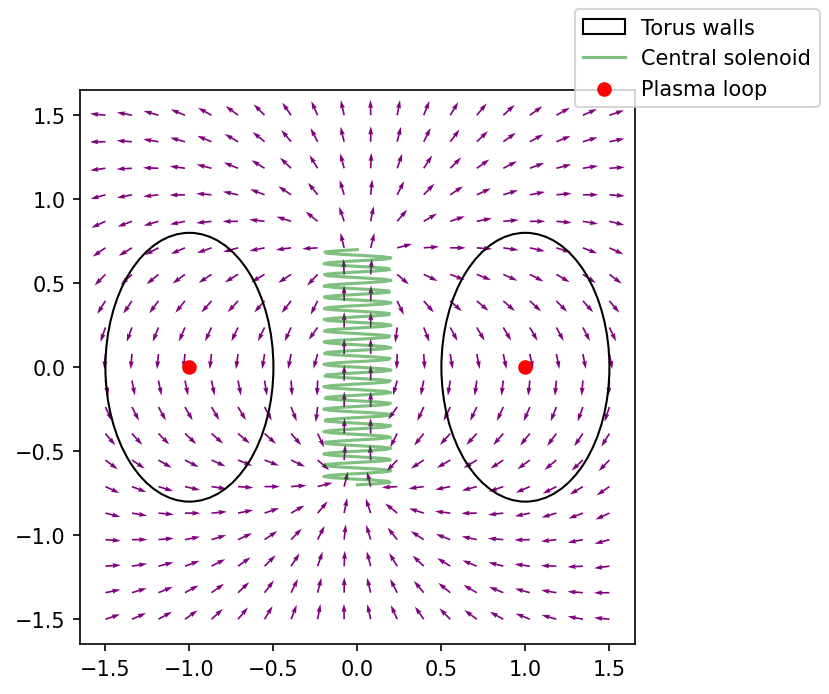

In [26]:
### Central solenoid cross section
### Same thing as for the poloidal coils
# Plot the field
rn = 0.5*np.sqrt(field[0]**2 + field[2]**2)
ax_2.quiver(xp[int(len(xp)/2)], zp[int(len(xp)/2)], field[0]/rn, field[2]/rn, color='purple')

# Circle patch for the torus walls
circ_1 = matplotlib.patches.Ellipse((1, 0), 1, 1.6, color=None, fill=False, label='Torus walls')
circ_2 = matplotlib.patches.Ellipse((-1, 0), 1, 1.6, color=None, fill=False)
ax_2.add_patch(circ_1)
ax_2.add_patch(circ_2)
#
# Coil
ax_2.plot(ploop_cs[0], ploop_cs[2], color='green', label='Central solenoid', alpha=0.5)
# Plasma
ax_2.scatter(-1, 0, color='red', label='Plasma loop')
ax_2.scatter(1, 0, color='red')
ax_2.set_aspect('equal')
fig_2.legend()

fig_2

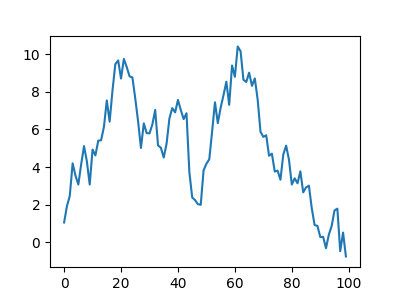

In [27]:
### Plasma current cross section
### Same thing as for the poloidal coils
# # Plot the field
rn = 0.5*np.sqrt(field[0]**2 + field[2]**2)
ax_2.quiver(xp[int(len(xp)/2)], zp[int(len(xp)/2)], field[0]/rn, field[2]/rn, color='purple')

# Circle patch for the torus walls
circ_1 = matplotlib.patches.Ellipse((1, 0), 1, 1.6, color=None, fill=False, label='Torus walls')
circ_2 = matplotlib.patches.Ellipse((-1, 0), 1, 1.6, color=None, fill=False)
ax_2.add_patch(circ_1)
ax_2.add_patch(circ_2)

# Plasma
ax_2.scatter(-1, 0, color='red', label='Plasma current')
ax_2.scatter(1, 0, color='red')

ax_2.set_aspect('equal')
plt.legend()
plt.show()

In [20]:
## Toroidal coild cross section
## Take slices like xp[:, :, :], yp[:, :, :], zp[:, :, int(len(zp)/2)]
# Plot the field
rn = 0.5*np.sqrt(field[0]**2 + field[1]**2)
ax_2.quiver(xp[:, :, int(len(zp)/2)], yp[:, :, int(len(yp)/2)], field[0]/rn, field[1]/rn, color='purple')

# Circle patch for the torus walls
circ_1 = matplotlib.patches.Circle((0, 0), (a + b), color=None, fill=False, label='Torus walls')
circ_2 = matplotlib.patches.Circle((0, 0), (b - a), color=None, fill=False)
ax_2.add_patch(circ_1)
ax_2.add_patch(circ_2)

# Coil
ax_2.plot(ploop_tor[0], ploop_tor[1], color='black', label='Toroidal coil', alpha=0.5)

ax_2.set_aspect('equal')
plt.legend()
plt.show()

Using matplotlib backend: widget
